### This jupyter notebook contains contents of the additional homework

**Author : Umidjon Sattorov. Machine Learning engineer**

| Column          | English Description                                                           | Русское описание                                                                  | O'zbekcha tavsifi                                                         |
| --------------- | ----------------------------------------------------------------------------- | --------------------------------------------------------------------------------- | ------------------------------------------------------------------------- |
| **age**         | Age of the patient in days.                                                   | Возраст пациента в днях.                                                          | Bemor yoshi (kunlarda).                                                   |
| **sex**         | Gender: `1` = Male, `2` = Female.                                             | Пол: `1` = Мужчина, `2` = Женщина.                                                | Jinsi: `1` = Erkak, `2` = Ayol.                                           |
| **height**      | Height in centimeters.                                                        | Рост в сантиметрах.                                                               | Boʻy (sm da).                                                             |
| **weight**      | Weight in kilograms.                                                          | Вес в килограммах.                                                                | Vazn (kg da).                                                             |
| **ap\_hi**      | Systolic blood pressure.                                                      | Систолическое давление.                                                           | Yuqori qon bosimi (sistolik).                                             |
| **ap\_lo**      | Diastolic blood pressure.                                                     | Диастолическое давление.                                                          | Pastki qon bosimi (diastolik).                                            |
| **cholesterol** | Cholesterol level: `1` = Normal, `2` = Above normal, `3` = Well above normal. | Уровень холестерина: `1` = Нормальный, `2` = Повышенный, `3` = Сильно повышенный. | Xolesterin darajasi: `1` = Normal, `2` = Biroz yuqori, `3` = Juda yuqori. |
| **gluc**        | Glucose level: same coding as cholesterol.                                    | Уровень глюкозы: те же значения, что и для холестерина.                           | Glyukoza darajasi: `1`, `2`, `3` — xuddi xolesterin kabi.                 |
| **smoke**       | Smokes: `0` = No, `1` = Yes.                                                  | Курит: `0` = Нет, `1` = Да.                                                       | Chekadimi: `0` = Yoʻq, `1` = Ha.                                          |
| **alco**        | Alcohol intake: `0` = No, `1` = Yes.                                          | Употребляет алкоголь: `0` = Нет, `1` = Да.                                        | Spirtli ichimlik ichadimi: `0` = Yoʻq, `1` = Ha.                          |
| **active**      | Physically active: `0` = No, `1` = Yes.                                       | Физически активен: `0` = Нет, `1` = Да.                                           | Jismoniy faolmi: `0` = Yoʻq, `1` = Ha.                                    |
| **cardio**      | Has cardiovascular disease: `0` = No, `1` = Yes.                              | Есть сердечно-сосудистое заболевание: `0` = Нет, `1` = Да.                        | Yurak-qon tomir kasalligi mavjudmi: `0` = Yoʻq, `1` = Ha.                 |


In [2]:
import pandas as pd
import numpy as np
import sklearn.preprocessing as sklp
import matplotlib.pyplot as plt
import seaborn as sns

    1. Импортируйте данные из файла medical_examination.csv и присвойте их переменной df.

In [53]:
df = pd.read_csv('medical_examination.csv')
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


    2. Добавьте в данные столбец overweight (избыточный вес).
    Чтобы определить, есть ли у человека избыточный вес, сначала рассчитайте его индекс массы тела (ИМТ), разделив массу тела в килограммах на квадрат роста в метрах.
    Если значение ИМТ > 25 — человек имеет избыточный вес.
    Используйте значение 0 — если НЕТ избыточного веса, и 1 — если ЕСТЬ.

In [4]:
df['height_metr'] = [float(f'{i // 100}{"."}{i % 100}') for i in df['height']] 
df['imt'] = [1 if i > 25 else 0 for i in (df['weight'] / (df['height_metr'] ** 2))]
df = df.drop(columns=['height_metr'])

    3. Нормализуйте данные, сделав 0 всегда "хорошим", а 1 — "плохим":
    Если значение cholesterol или gluc равно 1, установите его в 0.
    Если значение больше 1, установите его в 1.

In [5]:
df['cholesterol'] = [1 if i > 1 else 0 for i in df['cholesterol']]
df['gluc'] = [1 if i > 1 else 0 for i in df['gluc']]

    4. Нарисуйте категориальный график в функции draw_cat_plot.

In [ ]:
# Your code goes here


    5. Создайте DataFrame для категориального графика с помощью pd.melt.
    Используйте для этого значения из столбцов: cholesterol, gluc, smoke, alco, active, overweight и присвойте результат переменной df_cat.

In [10]:
# Your code goes here
df_cat = pd.melt(df, id_vars='cardio', value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'imt'])

In [11]:
df_cat

,cardio,variable,value
0,0,cholesterol,0
1,1,cholesterol,1
2,1,cholesterol,1
3,1,cholesterol,0
4,0,cholesterol,0
...,...,...,...
419995,0,imt,1
419996,1,imt,1
419997,1,imt,1
419998,1,imt,1


In [30]:
df_cat

,cardio,Feature,Amount
0,0,cholesterol,0
1,1,cholesterol,1
2,1,cholesterol,1
3,1,cholesterol,0
4,0,cholesterol,0
...,...,...,...
419995,0,overweight,1
419996,1,overweight,1
419997,1,overweight,1
419998,1,overweight,1


    6. Сгруппируйте и преобразуйте данные в df_cat, разделив их по признаку cardio.
    Отобразите количество каждого признака.
    Необходимо переименовать один из столбцов, чтобы catplot работал корректно.

In [15]:
df_cat = df_cat.groupby(["cardio", "variable", "value"]).size().reset_index(name="total")

,cardio,Feature,Amount,Total
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


    7. Преобразуйте данные в длинный формат и постройте график, показывающий количество значений категориальных признаков с помощью библиотеки seaborn и функции sns.catplot().

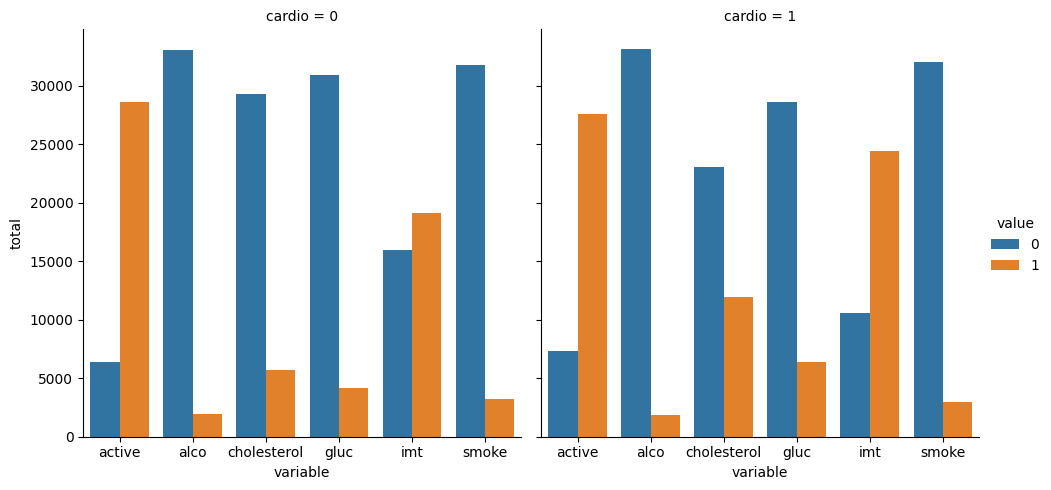

In [ ]:
sns.catplot(data=df_cat, x="variable", y="total", hue="value", col="cardio", kind="bar")

plt.show()

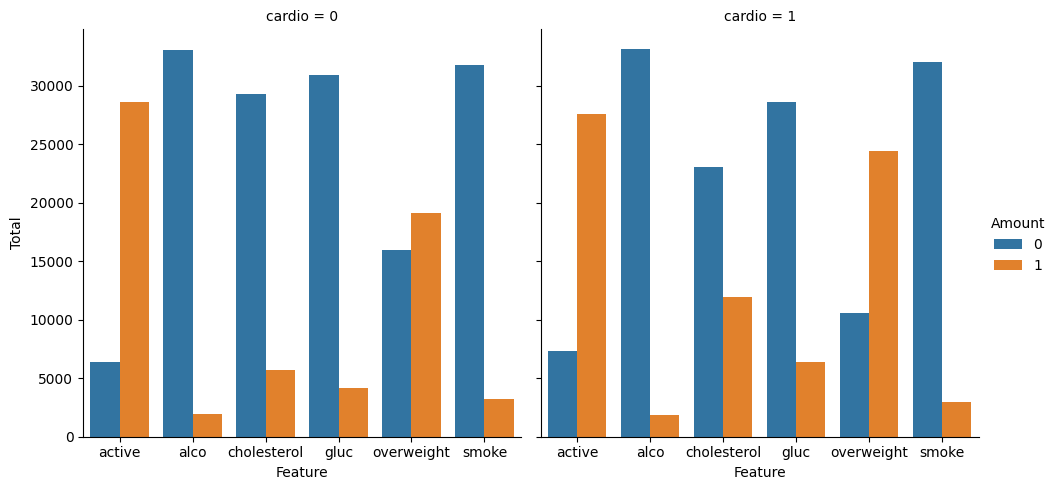

    8. Получите объект figure для вывода и сохраните его в переменной fig.

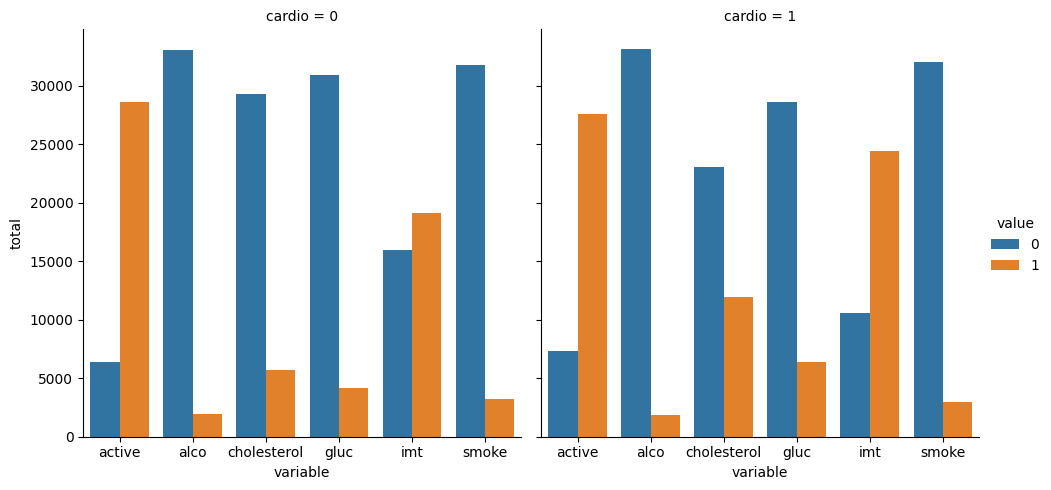

In [18]:
figure = sns.catplot(data=df_cat, x="variable", y="total", hue="value", col="cardio", kind="bar")
figure
plt.show()

    9. Постройте тепловую карту (Heat Map) в функции draw_heat_map.

    Очистите данные в переменной df_heat, отфильтровав следующие некорректные данные пациентов:

* Диастолическое давление больше систолического
(оставьте только строки, где df['ap_lo'] <= df['ap_hi'])

* Рост меньше 2.5-го процентиля
(оставьте строки, где df['height'] >= df['height'].quantile(0.025))

* Рост больше 97.5-го процентиля

* Вес меньше 2.5-го процентиля

* Вес больше 97.5-го процентиля

In [54]:
df = df.drop(df[df['ap_lo'] > df['ap_hi']].index)
df = df.drop(df[df['height'] < df['height'].quantile(0.025)].index)
df = df.drop(df[df['height'] > df['height'].quantile(0.975)].index)
df = df.drop(df[df['weight'] < df['weight'].quantile(0.025)].index)
df = df.drop(df[df['weight'] > df['weight'].quantile(0.975)].index)
df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70.0,130,90,1,1,0,0,1,1
69994,99992,21074,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


    10. Рассчитайте корреляционную матрицу и сохраните её в переменную corr

In [55]:
corr = df.corr()
corr

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
id,1.000000,0.002623,0.003799,0.000221,0.000144,0.003489,0.000429,0.005635,0.002383,-0.002403,-0.001039,0.005890,0.003770
age,0.002623,1.000000,-0.018274,-0.077426,0.069705,0.018482,0.152787,0.154134,0.098011,-0.044208,-0.026956,-0.011471,0.239987
sex,0.003799,-0.018274,1.000000,0.504722,0.130116,0.004941,0.059500,-0.038725,-0.023131,0.337682,0.169178,0.007702,0.001727
height,0.000221,-0.077426,0.504722,1.000000,0.248868,0.004300,0.015356,-0.067118,-0.029119,0.187389,0.089257,-0.005042,-0.025673
weight,0.000144,0.069705,0.130116,0.248868,1.000000,0.026527,0.223786,0.133912,0.091551,0.055805,0.058286,-0.012112,0.166886
ap_hi,0.003489,0.018482,0.004941,0.004300,0.026527,1.000000,0.072260,0.021282,0.010119,-0.001978,0.000607,-0.000162,0.050321
ap_lo,0.000429,0.152787,0.059500,0.015356,0.223786,0.072260,1.000000,0.152698,0.066235,0.022997,0.031839,0.002184,0.326125
cholesterol,0.005635,0.154134,-0.038725,-0.067118,0.133912,0.021282,0.152698,1.000000,0.451908,0.005769,0.030090,0.007712,0.217927
gluc,0.002383,0.098011,-0.023131,-0.029119,0.091551,0.010119,0.066235,0.451908,1.000000,-0.010409,0.005317,-0.007182,0.087316
smoke,-0.002403,-0.044208,0.337682,0.187389,0.055805,-0.001978,0.022997,0.005769,-0.010409,1.000000,0.341434,0.027203,-0.020605


    11. Сгенерируйте маску для верхнего треугольника и сохраните её в переменную mask

In [61]:
mask = np.triu(np.ones_like(corr))
mask

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False,  True,
         

    12.Настройте объект matplotlib.figure.

    Постройте корреляционную матрицу с помощью функции sns.heatmap() из библиотеки seaborn.

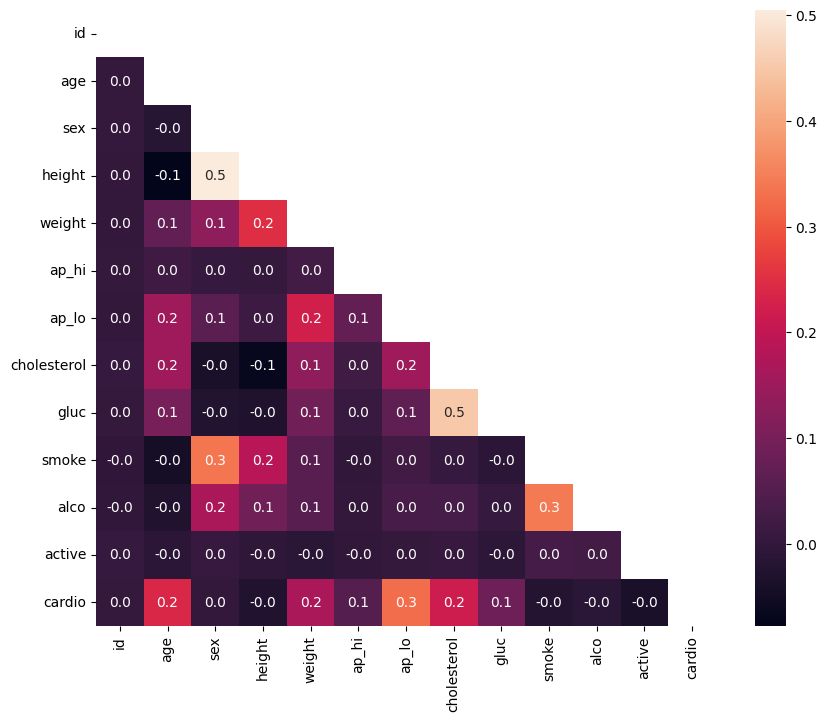

In [63]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, fmt='.1f', annot=True)
plt.show()

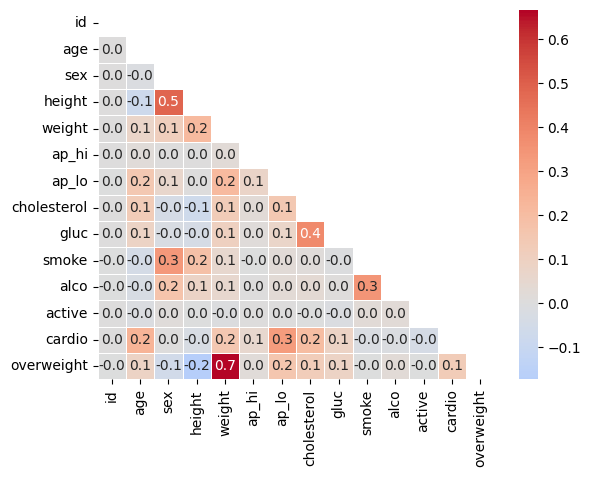

In [ ]:
# Your code goes here
